# - Important Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# - Set global font sizes

In [2]:
import matplotlib as mpl
# Set global font sizes
mpl.rcParams.update({
    'font.size': 12,             # Base font size
    'axes.titlesize': 14,        # Title size of each subplot
    'axes.labelsize': 12,        # x and y axis label size
    'xtick.labelsize': 12,       # X tick label size
    'ytick.labelsize': 12,       # Y tick label size
    'legend.fontsize': 12,       # Legend text size
    'figure.titlesize': 12,      # Main figure title
    'legend.fontsize': 12        # Legend text size
})


# - A Single process with disruption without inventory management 

In [5]:
#######################################################################################################################
# Helpers for disruptions: 2-state (Up=1 / Down=0) CTMC simulation and per-step availability
#######################################################################################################################

##--- Simulate a 2-state CTMC (Up=1, Down=0) over [0, T_total) with rates Up--alpha-->Down, Down--beta-->Up ---##
def simulate_2state_ctmc(alpha, beta, T_total):
    if (alpha + beta) > 0:                                 # alpha=q_{1,0}, beta=q_{0,1}
        p_up = beta / (alpha + beta)                       # stationary probability of Up
    else:
        p_up = 1.0                                         # always Up if no transitions

    current_state = 1 if np.random.random() < p_up else 0
    t = 0.0
    states = [current_state]
    times = []

    ## --- Compute the sojourn times and state transitions ---##
    while t < T_total:
        rate = alpha if current_state == 1 else beta
        rate = max(rate, 1e-12)                            # avoid division by zero
        sojourn = np.random.exponential(1.0 / rate)
        t_next = t + sojourn
        times.append(t_next)
        if t_next >= T_total:
            break
        current_state = 1 - current_state
        states.append(current_state)
        t = t_next

    return np.column_stack([np.array(states), np.array(times)])


## --- Compute fraction of time process is Up within [t0, t1) ---##
def availability_in_interval(t0, t1, states_times):
    if t1 <= t0:
        return 0.0
    ends = states_times[:, 1]
    states = states_times[:, 0]
    starts = np.concatenate([[0.0], ends[:-1]])
    up_time = 0.0
    for s, e, st in zip(starts, ends, states):
        if e <= t0 or s >= t1:
            continue
        overlap = min(e, t1) - max(s, t0)
        if overlap > 0 and st == 1:
            up_time += overlap
    return up_time / (t1 - t0)


#######################################################################################################################
# Stochastic transport / production system — with optional process disruptions
#  Each process follows a 2-state CTMC (Up/Down)
#######################################################################################################################

def basic_sc_disrupt(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N, alpha_down=None, beta_up=None):
    time = np.arange(0, T + tau, tau)
    num_steps = len(time)
    X_all = np.zeros((N, nd, num_steps))

    USE_DISRUPT = (alpha_down is not None) and (beta_up is not None)
    if USE_DISRUPT:
        alpha_down = np.asarray(alpha_down)
        beta_up = np.asarray(beta_up)
        if alpha_down.shape != (J,) or beta_up.shape != (J,):
            raise ValueError("alpha_down and beta_up must be length-J arrays.")

    for r in range(N):
        X = np.zeros((nd, num_steps))
        count = 0
        X[:, count] = np.array([1000, 0])

        queue_delay = []                        # list of [process_id, t_next_check, Q_remaining, remaining_span]
        t = 0.0

        # --- Initialize CTMC chains for each process ---
        chains = [None] * J
        if USE_DISRUPT:
            for j in range(J):
                chains[j] = simulate_2state_ctmc(alpha_down[j], beta_up[j], T)

#######################################################################################################################
# Instantaneous consumption algorithm starts here
#######################################################################################################################
        while t < T:
            X[:, count + 1] = X[:, count]

            ####------- Availability for each process within [t, t+tau) -------####
            if USE_DISRUPT:
                D_j_t = np.array([availability_in_interval(t, t + tau, chains[j]) for j in range(J)])
            else:
                D_j_t = np.ones(J)

            # --- Sample consumption events ---
            Delta_C_j = np.random.poisson((lambda_j * D_j_t) * tau)

            # --- Cap consumption by available inventory ---
            for j in range(J):
                for k in range(nd):
                    if C_j_c[k, j] < 0:
                        max_possible = int(X[k, count + 1] / abs(C_j_c[k, j]))
                        Delta_C_j[j] = min(Delta_C_j[j], max_possible)

            # --- Apply consumption immediately ---
            X[:, count + 1] += C_j_c @ Delta_C_j

            # --- Queue production completions ---
            for j in range(J):
                d_nq = j
                t_nq_s = t + pT[j, 0]
                Q_nq_d = Delta_C_j[j]                          # jobs entering production
                t_span = tau + (pT[j, 1] - pT[j, 0])
                queue_delay.append([d_nq, t_nq_s, Q_nq_d, t_span])

#######################################################################################################################
# Delayed production algorithm starts here
#######################################################################################################################
            if queue_delay:
                new_queue = []
                for d_nq, t_nq_s, Q_nq_d, t_span in queue_delay:
                    if t_span > 0 and (t <= t_nq_s < t + tau):

                        ####------- Availability during [t_nq_s, min(t_nq_s+t_span, t+tau)) -------####
                        if USE_DISRUPT:
                            t_end = min(t_nq_s + t_span, t + tau)
                            D_d_nq = availability_in_interval(t_nq_s, t_end, chains[d_nq])
                        else:
                            D_d_nq = 1.0

                        # --- Effective completion probability ---
                        prob = min(((t + tau - t_nq_s) / t_span) * D_d_nq, 1.0)
                        # --- Binomial draw for completions ---
                        Delta_P_j = np.random.binomial(Q_nq_d, prob)
                        Q_nq_d -= Delta_P_j

                        # --- Advance delay parameters ---
                        t_nq_s = t + tau
                        t_span = max(0, t_span - (t + tau - t_nq_s))

                        # --- Apply production increments ---
                        Delta_P_j_vec = np.zeros(J)
                        Delta_P_j_vec[d_nq] = Delta_P_j
                        X[:, count + 1] += C_j_p @ Delta_P_j_vec

                        if Q_nq_d > 0:
                            new_queue.append([d_nq, t_nq_s, Q_nq_d, t_span])
                    else:
                        new_queue.append([d_nq, t_nq_s, Q_nq_d, t_span])

                queue_delay = new_queue

            # --- Advance time ---
            if (t + tau) >= T:
                tau = T - t 
            t += tau
            count += 1
#######################################################################################################################
# Delayed production algorithm ends here
#######################################################################################################################

        X_all[r] = X

    X_avg = np.mean(X_all, axis=0)
    X_std = np.std(X_all, axis=0)
    return X_avg, X_std, time
#######################################################################################################################
# END OF FUNCTION
#######################################################################################################################


#######################################################################################################################
# Problem setup
#######################################################################################################################
nd = 2                                        # total number of dimensions (number of parts)
J = 1                                         # total number of processes
N = 500                                       # number of Monte Carlo paths
T = 120                                       # Total simulation time
tau = 2

# Production window per process: [start, end]
pT = np.array([[10, 10]])                    # shape (J,2)       with no delay start = end

# Stoichiometry (nd x J)  — process consumes state 0 and produces state 1
C_j_c = np.array([[-1],
                  [ 0]])                    # (2,1)
C_j_p = np.array([[0],
                  [1]])                     # (2,1)

# Base event rates per process (shape J,)
lambda_j = np.array([10.0])


#######################################################################################################################
# General make_rates for all processes
#######################################################################################################################
def make_rates(J, alpha_vals, beta_vals):
    rates = np.zeros((J, 2))
    alpha_arr = np.full(J, alpha_vals) if np.isscalar(alpha_vals) else np.array(alpha_vals)
    beta_arr  = np.full(J, beta_vals) if np.isscalar(beta_vals)  else np.array(beta_vals)
    if alpha_arr.size != J or beta_arr.size != J:
        raise ValueError(f"alpha_vals and beta_vals must be scalars or length {J}.")
    rates[:, 0] = alpha_arr
    rates[:, 1] = beta_arr
    return rates


# - Simulating a basic supply chain dynamics with and without disruption with fixed delay

In [7]:
######################################################################################################################
# Define scenarios (including No disruptions)
#######################################################################################################################

scenarios = {"No disruption": None,
    "Disruption": make_rates(J, alpha_vals=[0.1], beta_vals=[0.5]),
    "Disruption x3": make_rates(J, alpha_vals=[0.3], beta_vals=[0.5]),}

#######################################################################################################################
# Run all scenarios
#######################################################################################################################

results = {}

for label, rates in scenarios.items():
    if rates is None:
        # No disruptions: alpha_down = beta_up = 0
        X_avg, X_std, time = basic_sc_disrupt(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N,alpha_down=None, beta_up=None)
    else:
        alpha_down = rates[:, 0]
        beta_up    = rates[:, 1]
        X_avg, X_std, time = basic_sc_disrupt(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N, alpha_down=alpha_down, beta_up=beta_up)

    # Store the second state (index 1). With nd=2, valid indices are 0 and 1.
    results[label] = {"time": time,
                      "mean": X_avg[1],
                      "std": X_std[1]}


# Print Out

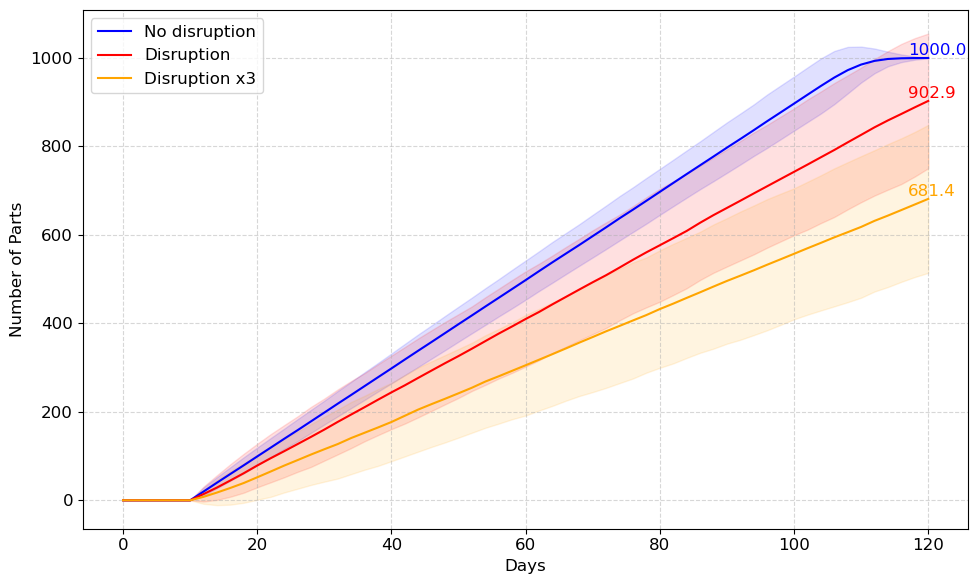

In [8]:
#######################################################################################################################
# Plot with fill_between
#######################################################################################################################
plt.figure(figsize=(10, 6))
colors = {"No disruption": "blue", "Disruption": "red", "Disruption x3": "orange"}

for label, data in results.items():
    t_grid = data["time"]
    y_mean = data["mean"]
    y_std = data["std"]
    color = colors[label]

    plt.plot(t_grid, y_mean, color=color, linewidth=1.5, label=label)
    plt.fill_between(t_grid, y_mean-2*y_std, y_mean+2*y_std, alpha = 0.12, color=color)
    plt.text(t_grid[-1]-3, y_mean[-1], f"{y_mean[-1]:.1f}", color=color, va="bottom")

plt.ylabel('Number of Parts')
plt.xlabel('Days')
# plt.title(fr"With and without disruption but fixed delay: $\left[\hat{{t}}^{{\min}},\ \hat{{t}}^{{\max}}\right]=\left[{pT[0,0]},\ {pT[0,1]}\right]$")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("disrupt_nodisrupt_fix_delay.png", format='png', bbox_inches='tight')

plt.show()

# - Simulating a basic supply chain dynamics with and without disruption with fixed delay with slope of the trajectories

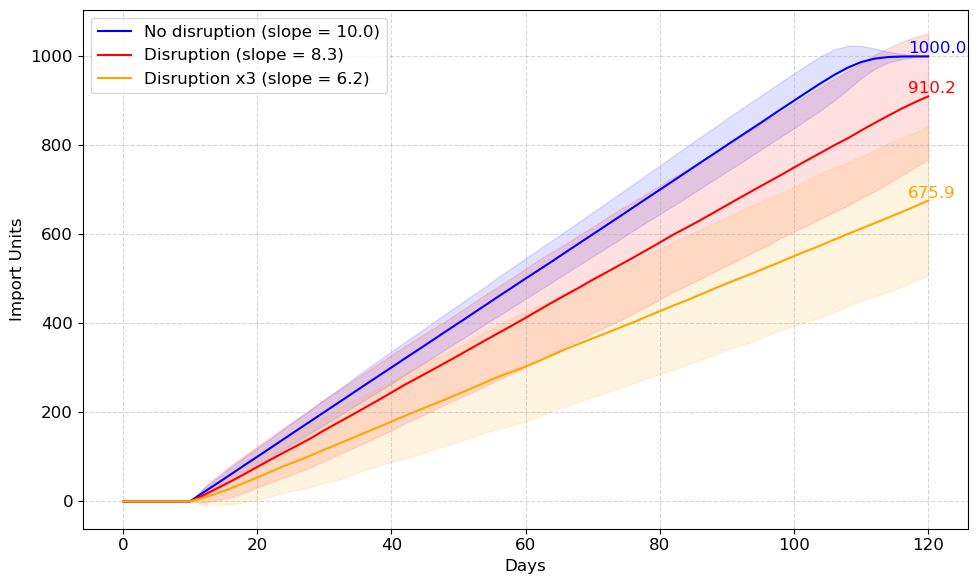

In [22]:
#######################################################################################################################
# Define scenarios (including No disruptions)
#######################################################################################################################

scenarios = {"No disruption": None,
    "Disruption": make_rates(J, alpha_vals=[0.1], beta_vals=[0.5]),
    "Disruption x3": make_rates(J, alpha_vals=[0.3], beta_vals=[0.5]),}

#######################################################################################################################
# Run simulations, compute average slopes
#######################################################################################################################

results = {}
for label, rates in scenarios.items():
    if rates is None:
        X_avg, X_std, time = basic_sc_disrupt(nd, J, T, tau, pT, C_j_c, C_j_p,lambda_j, N)
        expected_valid = 1.0
    else:
        alpha_down, beta_up = rates[:, 0], rates[:, 1]
        X_avg, X_std, time = basic_sc_disrupt(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N, alpha_down=alpha_down, beta_up=beta_up)
        expected_valid = beta_up[0] / (beta_up[0] + alpha_down[0])

    # Expected slope for trajectory
    Expected_slope = lambda_j[0] * expected_valid
    results[label] = {"time": time,"mean": X_avg,"std": X_std, "slope": Expected_slope      # final slope for X₂(t)
    }

#######################################################################################################################
# Plot average trajectories with slope in legend
#######################################################################################################################

plt.figure(figsize=(10, 6))
colors = {"No disruption": "blue", "Disruption": "red", "Disruption x3": "orange"}

for label, data in results.items():
    t_grid = data["time"]
    y_mean = data["mean"][1]   # X₂(t)
    y_std = data["std"][1]
    color = colors[label]
    Expected_slope = data["slope"]

    plt.plot(t_grid, y_mean, color=color, linewidth=1.5, label=f"{label} (slope = {Expected_slope:.1f})")
    plt.fill_between(t_grid, y_mean - 2*y_std, y_mean + 2*y_std, alpha=0.12, color=color)
    plt.text(t_grid[-1]-3, y_mean[-1], f"{y_mean[-1]:.1f}", color=color, va="bottom")

plt.xlabel("Days")
plt.ylabel("Import Units")
# plt.title("Average Trajectories with Final Slope in Legend")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# - Simulating supply chain dynamics with a fixed delay and variable delay period with and without disruption

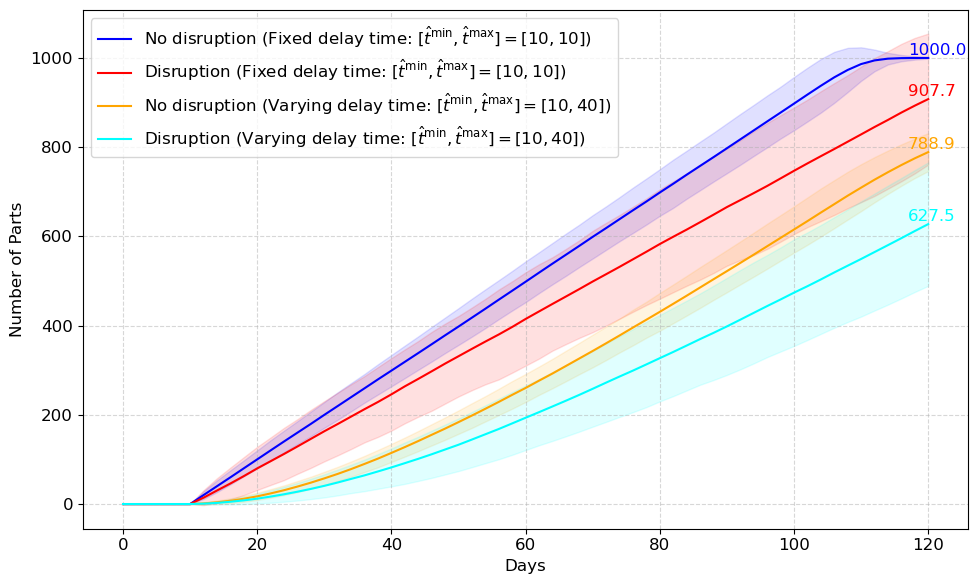

In [10]:
# #######################################################################################################################
# Fixed delay and variable delay cases
# #######################################################################################################################

pT_fixed = np.array([[10, 10]])   # fixed 10 days
pT_var   = np.array([[10, 40]])   # variable 10–40 days

#######################################################################################################################
# Define scenarios 
#######################################################################################################################
scenarios = {
    "No disruption": None,
    "Disruption": make_rates(J, alpha_vals=[0.1], beta_vals=[0.5]),
    # "Disruption x2": make_rates(J,alpha_vals=[0.2], beta_vals=[0.5]),
}

#######################################################################################################################
# Run for both delay cases
#######################################################################################################################
def run_all_cases(pT_label, pT):
    result_case = {}
    for label, rates in scenarios.items():
        if rates is None:
            X_avg, X_std, time = basic_sc_disrupt(nd, J, T, tau, pT, C_j_c, C_j_p,lambda_j, N, alpha_down=None, beta_up=None)
        else:
            alpha_down = rates[:, 0]
            beta_up = rates[:, 1]
            X_avg, X_std, time = basic_sc_disrupt(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N, alpha_down=alpha_down, beta_up=beta_up)
        result_case[label] = {"time": time, "mean": X_avg[1], "std": X_std[1]}
    return result_case

results_fixed = run_all_cases("Fixed", pT_fixed)
results_var   = run_all_cases("Varying", pT_var)

#######################################################################################################################
# Plot comparison — each scenario and delay has its own color
#######################################################################################################################
plt.figure(figsize=(10, 6))

# Unique colors per (scenario, delay) combination
color_map = {
    ("No disruption", "Fixed"): "blue",
    ("No disruption", "Varying"): "orange",
    ("Disruption", "Fixed"): "red",
    ("Disruption", "Varying"): "cyan",
}

# --- Plot fixed delay cases ---
for label, data in results_fixed.items():
    t_grid = data["time"]
    y_mean = data["mean"]
    y_std = data["std"]
    color = color_map[(label, "Fixed")]
    plt.plot(t_grid, y_mean, color=color, linewidth=1.5,
             label=fr"{label} (Fixed delay time: $[\hat{{t}}^{{\min}},\hat{{t}}^{{\max}}]=[{pT_fixed[0,0]}, {pT_fixed[0,1]}]$)")
    plt.fill_between(t_grid, y_mean - 2*y_std, y_mean + 2*y_std, color=color, alpha=0.12)
    plt.text(t_grid[-1]-3, y_mean[-1], f"{y_mean[-1]:.1f}", color=color, va="bottom")

# --- Plot varying delay cases ---
for label, data in results_var.items():
    t_grid = data["time"]
    y_mean = data["mean"]
    y_std = data["std"]
    color = color_map[(label, "Varying")]
    plt.plot(t_grid, y_mean, color=color, linewidth=1.5,
             label=fr"{label} (Varying delay time: $[\hat{{t}}^{{\min}},\hat{{t}}^{{\max}}]=[{pT_var[0,0]}, {pT_var[0,1]}]$)")
    plt.fill_between(t_grid, y_mean - 2*y_std, y_mean + 2*y_std, color=color, alpha=0.12)
    plt.text(t_grid[-1]-3, y_mean[-1], f"{y_mean[-1]:.1f}", color=color, va="bottom")

# --- Formatting ---
plt.xlabel("Days")
plt.ylabel("Number of Parts")
# plt.title(fr"Comparison of Disruption Scenarios (T={T} days)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("fix_var_with_without_disrupt.png", format='png', bbox_inches='tight')

plt.show()

# CODE WITH REPLENISHMENT ORDER

# - A single process to compare the impact of disruption vs no disruption on the import rates, using L-leap method with inventory management

In [71]:
#######################################################################################################################
# Helpers for disruptions: 2-state (Up=1 / Down=0) CTMC simulation and per-step availability
#######################################################################################################################
import numpy as np

np.random.seed(42)

##--- Simulate a 2-state CTMC (Up=1, Down=0) over [0, T_total) with rates Up--alpha-->Down, Down--beta-->Up ---##
def simulate_2state_ctmc(alpha, beta, T_total):
    if (alpha + beta) > 0:                                 # alpha=q_{1,0}, beta=q_{0,1}
        p_up = beta / (alpha + beta)                       # stationary probability of Up
    else:
        p_up = 1.0                                         # always Up if no transitions

    current_state = 1 if np.random.random() < p_up else 0
    t = 0.0
    states = [current_state]
    times = []

    ## --- Compute the sojourn times and state transitions ---##
    while t < T_total:
        rate = alpha if current_state == 1 else beta
        rate = max(rate, 1e-12)                            # avoid division by zero
        sojourn = np.random.exponential(1.0 / rate)
        t_next = t + sojourn
        times.append(t_next)
        if t_next >= T_total:
            break
        current_state = 1 - current_state
        states.append(current_state)
        t = t_next

    return np.column_stack([np.array(states), np.array(times)])


## --- Compute fraction of time process is Up within [t0, t1) ---##
def availability_in_interval(t0, t1, states_times):
    if t1 <= t0:
        return 0.0
    ends = states_times[:, 1]
    states = states_times[:, 0]
    starts = np.concatenate([[0.0], ends[:-1]])
    up_time = 0.0
    for s, e, st in zip(starts, ends, states):
        if e <= t0 or s >= t1:
            continue
        overlap = min(e, t1) - max(s, t0)
        if overlap > 0 and st == 1:
            up_time += overlap
    return up_time / (t1 - t0)


#######################################################################################################################
# Stochastic transport / production system — with optional process disruptions
#  Each process follows a 2-state CTMC (Up/Down)
#######################################################################################################################

def basic_sc_disrupt(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N, alpha_down=None, beta_up=None, X_s1=10, S_p1=10):
    time = np.arange(0, T + tau, tau)
    num_steps = len(time)
    X_all = np.zeros((N, nd, num_steps))

    USE_DISRUPT = (alpha_down is not None) and (beta_up is not None)
    if USE_DISRUPT:
        alpha_down = np.asarray(alpha_down)
        beta_up = np.asarray(beta_up)
        if alpha_down.shape != (J,) or beta_up.shape != (J,):
            raise ValueError("alpha_down and beta_up must be length-J arrays.")

    for r in range(N):
        X = np.zeros((nd, num_steps))
        count = 0
        X[:, count] = np.array([1000, 0])

        queue_delay = []                        # list of [process_id, t_next_check, Q_remaining, remaining_span]
        t = 0.0

        # --- Initialize CTMC chains for each process ---
        chains = [None] * J
        if USE_DISRUPT:
            for j in range(J):
                chains[j] = simulate_2state_ctmc(alpha_down[j], beta_up[j], T)

#######################################################################################################################
# Instantaneous consumption algorithm starts here
#######################################################################################################################
        while t < T:
            X[:, count + 1] = X[:, count]


            ### --------- Replenished Order Strategy --------- ###          
            # Safety stock replenishment (add S_p1 when under threshold)
            if X[0, count + 1] <= X_s1:
                X[0, count + 1] = X_s1 - X[0, count + 1] + S_p1

            ####------- Availability for each process within [t, t+tau) -------####
            if USE_DISRUPT:
                D_j_t = np.array([availability_in_interval(t, t + tau, chains[j]) for j in range(J)])
            else:
                D_j_t = np.ones(J)

            # --- Sample consumption events ---
            Delta_C_j = np.random.poisson((lambda_j * D_j_t) * tau)

            # --- Cap consumption by available inventory ---
            for j in range(J):
                for k in range(nd):
                    if C_j_c[k, j] < 0:
                        max_possible = int(X[k, count + 1] / abs(C_j_c[k, j]))
                        Delta_C_j[j] = min(Delta_C_j[j], max_possible)

            # --- Apply consumption immediately ---
            X[:, count + 1] += C_j_c @ Delta_C_j

            # --- Queue production completions ---
            for j in range(J):
                d_nq = j
                t_nq_s = t + pT[j, 0]
                Q_nq_d = Delta_C_j[j]                          # jobs entering production
                t_span = tau + (pT[j, 1] - pT[j, 0])
                queue_delay.append([d_nq, t_nq_s, Q_nq_d, t_span])

#######################################################################################################################
# Delayed production algorithm starts here
#######################################################################################################################
            if queue_delay:
                new_queue = []
                for d_nq, t_nq_s, Q_nq_d, t_span in queue_delay:
                    if t_span > 0 and (t <= t_nq_s < t + tau):

                        ####------- Availability during [t_nq_s, min(t_nq_s+t_span, t+tau)) -------####
                        if USE_DISRUPT:
                            t_end = min(t_nq_s + t_span, t + tau)
                            D_d_nq = availability_in_interval(t_nq_s, t_end, chains[d_nq])
                        else:
                            D_d_nq = 1.0

                        # --- Effective completion probability ---
                        prob = min(((t + tau - t_nq_s) / t_span) * D_d_nq, 1.0)
                        # --- Binomial draw for completions ---
                        Delta_P_j = np.random.binomial(Q_nq_d, prob)
                        Q_nq_d -= Delta_P_j

                        # --- Advance delay parameters ---
                        t_nq_s = t + tau
                        t_span = max(0, t_span - (t + tau - t_nq_s))

                        # --- Apply production increments ---
                        Delta_P_j_vec = np.zeros(J)
                        Delta_P_j_vec[d_nq] = Delta_P_j
                        X[:, count + 1] += C_j_p @ Delta_P_j_vec

                        if Q_nq_d > 0:
                            new_queue.append([d_nq, t_nq_s, Q_nq_d, t_span])
                    else:
                        new_queue.append([d_nq, t_nq_s, Q_nq_d, t_span])

                queue_delay = new_queue

            # --- Advance time ---
            if (t + tau) >= T:
                tau = T - t 
            t += tau
            count += 1
#######################################################################################################################
# Delayed production algorithm ends here
#######################################################################################################################

        X_all[r] = X

    X_avg = np.mean(X_all, axis=0)
    X_std = np.std(X_all, axis=0)
    return X_avg, X_std, time
#######################################################################################################################
# END OF FUNCTION
#######################################################################################################################

# - Simulating a basic supply chain dynamics with and without disruption with fixed delay and with Replenishment Order

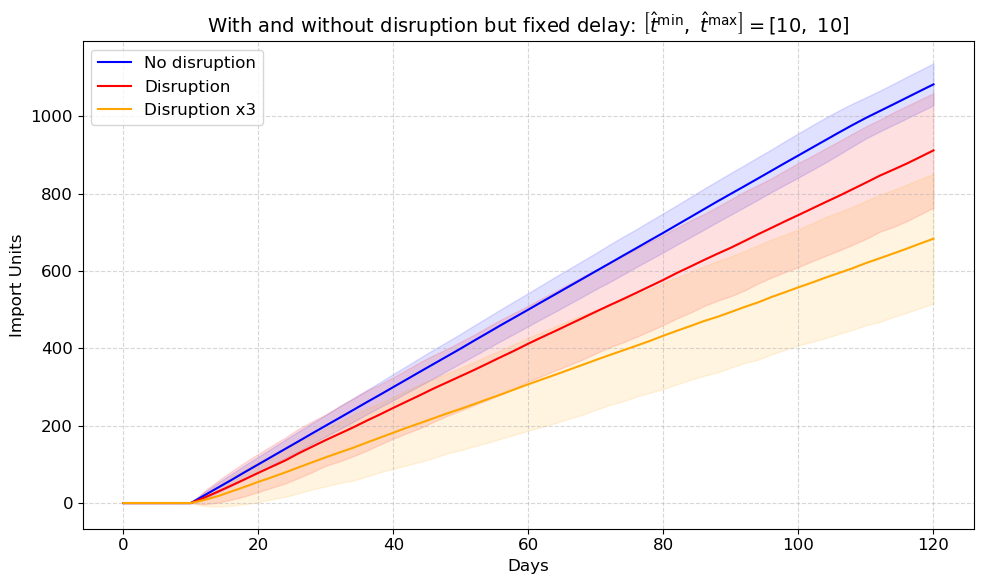

In [73]:
#######################################################################################################################
# Problem setup
#######################################################################################################################
nd = 2                                        # total number of dimensions (number of parts)
J = 1                                         # total number of processes
N = 500                                       # number of Monte Carlo paths
T = 120                                       # Total simulation time
tau = 2

# Production window per process: [start, end]
pT = np.array([[10, 10]])                    # shape (J,2)       with no delay start = end

# Stoichiometry (nd x J)  — process consumes state 0 and produces state 1
C_j_c = np.array([[-1],
                  [ 0]])                    # (2,1)
C_j_p = np.array([[0],
                  [1]])                     # (2,1)

# Base event rates per process (shape J,)
lambda_j = np.array([10.0])


#######################################################################################################################
# General make_rates for all processes
#######################################################################################################################
def make_rates(J, alpha_vals, beta_vals):
    rates = np.zeros((J, 2))
    alpha_arr = np.full(J, alpha_vals) if np.isscalar(alpha_vals) else np.array(alpha_vals)
    beta_arr  = np.full(J, beta_vals) if np.isscalar(beta_vals)  else np.array(beta_vals)
    if alpha_arr.size != J or beta_arr.size != J:
        raise ValueError(f"alpha_vals and beta_vals must be scalars or length {J}.")
    rates[:, 0] = alpha_arr
    rates[:, 1] = beta_arr
    return rates


#######################################################################################################################
# Define scenarios (including No disruptions)
#######################################################################################################################

scenarios = {"No disruption": None,
    "Disruption": make_rates(J, alpha_vals=[0.1], beta_vals=[0.5]),
    "Disruption x3": make_rates(J, alpha_vals=[0.3], beta_vals=[0.5]),}

#######################################################################################################################
# Run all scenarios
#######################################################################################################################

results = {}

for label, rates in scenarios.items():
    if rates is None:
        # No disruptions: alpha_down = beta_up = 0
        X_avg, X_std, time = basic_sc_disrupt(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N,alpha_down=None, beta_up=None, X_s1=10, S_p1=10)
    else:
        # alpha_down = rates[:, 0]
        # beta_up    = rates[:, 1]
        X_avg, X_std, time = basic_sc_disrupt(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N, alpha_down=rates[:, 0], 
                                                  beta_up=rates[:, 1], X_s1=10, S_p1=10)

    results[label] = {"time": time,
                      "mean": X_avg[1],
                      "std": X_std[1]}

#######################################################################################################################
# Plot with fill_between
#######################################################################################################################
plt.figure(figsize=(10, 6))
colors = {"No disruption": "blue", "Disruption": "red", "Disruption x3": "orange"}

for label, data in results.items():
    t_grid = data["time"]
    y_mean = data["mean"]
    y_std = data["std"]
    color = colors[label]

    plt.plot(t_grid, y_mean, color=color, linewidth=1.5, label=label)
    plt.fill_between(t_grid, y_mean-2*y_std, y_mean+2*y_std, alpha = 0.12, color=color)

plt.ylabel('Import Units')
plt.xlabel('Days')
plt.grid(True, linestyle='--', alpha=0.5)
plt.title(fr"With and without disruption but fixed delay: $\left[\hat{{t}}^{{\min}},\ \hat{{t}}^{{\max}}\right]=\left[{pT[0,0]},\ {pT[0,1]}\right]$")
plt.legend()
plt.tight_layout()
plt.savefig("disrupt_nodisrupt_TSC_replenish.png", format='png', bbox_inches='tight')

plt.show()

# - Simulating supply chain dynamics with a fixed delay and variable delay period without disruption using inventory management

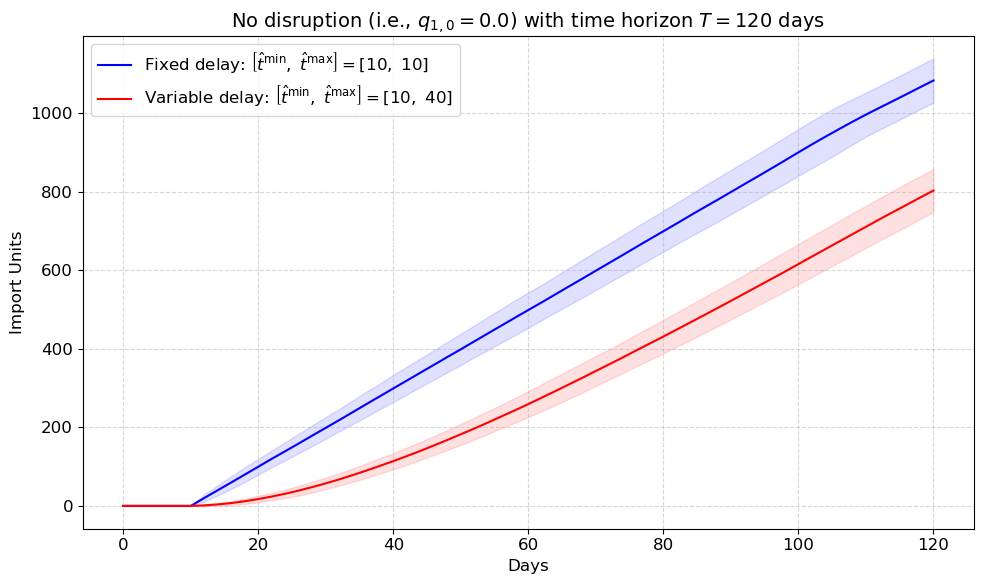

In [74]:
#######################################################################################################################
# Simulation parameters
#######################################################################################################################

# Fixed delay and variable delay cases
pT_fixed = np.array([[10, 10]])                       # fixed 10 days
pT_var   = np.array([[10, 40]])                       # variable 10–40 days

#######################################################################################################################
# Rate configurations
#######################################################################################################################
def make_rates(J, alpha_vals, beta_vals):
    rates = np.zeros((J, 2))
    rates[:, 0] = np.full(J, alpha_vals)
    rates[:, 1] = np.full(J, beta_vals)
    return rates

scenarios = {
    "No disruption": None,
}

#######################################################################################################################
# Run for both delay cases
#######################################################################################################################
def run_all_cases(pT_label, pT):
    result_case = {}
    for label, rates in scenarios.items():
        if rates is None:
            X_avg, X_std, time = basic_sc_disrupt(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N,alpha_down=None, beta_up=None, X_s1=10, S_p1=10)
        else:
            alpha_down = rates[:, 0]
            beta_up = rates[:, 1]
            X_avg, X_std, time = basic_sc_disrupt(nd, J, T, tau, pT, C_j_c, C_j_p, lambda_j, N, alpha_down=alpha_down, 
                                                  beta_up=beta_up, X_s1=10, S_p1=10)
            
        result_case[label] = {"time": time, "mean": X_avg[1], "std": X_std[1]}
    return result_case

results_fixed = run_all_cases("Fixed", pT_fixed)
results_var   = run_all_cases("Variable", pT_var)

#######################################################################################################################
# Plot comparison
#######################################################################################################################
plt.figure(figsize=(10, 6))
# colors = {"No disruption": "blue", "Disruption": "orange", "Disruption x2": "red"}

for label, data in results_fixed.items():
    t_grid = data["time"]
    y_mean = data["mean"]
    y_std = data["std"]
    plt.plot(t_grid, y_mean, color='blue', linewidth=1.5, 
             label=fr"Fixed delay: $\left[\hat{{t}}^{{\min}},\ \hat{{t}}^{{\max}}\right]=\left[{pT_fixed[0,0]},\ {pT_fixed[0,1]}\right]$")
    plt.fill_between(t_grid, y_mean - 2*y_std, y_mean + 2*y_std, color='blue', alpha=0.12)

for label, data in results_var.items():
    t_grid = data["time"]
    y_mean = data["mean"]
    y_std = data["std"]
    plt.plot(t_grid, y_mean, color='red', linewidth=1.5, 
             label=fr"Variable delay: $\left[\hat{{t}}^{{\min}},\ \hat{{t}}^{{\max}}\right]=\left[{pT_var[0,0]},\ {pT_var[0,1]}\right]$")
    plt.fill_between(t_grid, y_mean - 2*y_std, y_mean + 2*y_std, color='red', alpha=0.12)

plt.xlabel("Days")
plt.ylabel("Import Units")
plt.title(fr"{label} (i.e., $q_{{1,0}}=0.0$) with time horizon $T={T}$ days")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("fix_var_without_disrupt_replenish.png", format='png', bbox_inches='tight')
plt.show()